<a href="https://colab.research.google.com/github/vlhsilvia/TRABAJOS-PRACTICOS/blob/Silviamaster/segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Escuela de Primavera - 2025
*Instituto de Altos Estudios Espaciales "Mario Gulich" (CONAE - UNC)*



# Agricultural Field Boundary Segmentation using U-Net and Fields of The World (FTW) Dataset

This notebook we are going to implement two approaches for performing agricultural field boundary segmentation:

1.  **Simple U-Net Implementation:** Building and training a basic U-Net model from scratch.
2.  **U-Net with Pre-trained Encoder (Segmentation Models Library):** Utilizing transfer learning by using a pre-trained encoder (ResNet34) within a U-Net architecture from the `segmentation_models` library.


**About the dataset**

*Fields of The World: A Comprehensive Benchmark Dataset for Agricultural Field Boundaries*

It is a comprehensive benchmark dataset designed to enhance the development of machine learning models for instance segmentation of agricultural field boundaries. It aggregates and harmonizes a number of open datasets into 1.6 million parcel boundaries and over 70,000 samples covering diverse agricultural landscapes across 4 continents and 24 countries.

https://fieldsofthe.world/

https://arxiv.org/pdf/2409.16252

In [ ]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 61.7 MB/s eta 0:00:00


In [ ]:
# Import necessary libraries for semantic segmentation
import os
import matplotlib.pyplot as plt

# Suppress TensorFlow warnings and CUDA messages
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppress TensorFlow info and warning messages
os.environ['CUDA_VISIBLE_DEVICES'] = '0'  # Use only the first GPU if multiple GPUs are available

import tensorflow as tf
import keras
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, concatenate, Dropout, Conv2DTranspose
from tensorflow.keras.models import Model
from tensorflow.keras.utils import plot_model

# Additional TensorFlow logging configuration
tf.get_logger().setLevel('ERROR')  # Only show error messages

import utils

import pandas as pd

In [ ]:
tf.config.list_logical_devices()

[LogicalDevice(name='/device:CPU:0', device_type='CPU'),
 LogicalDevice(name='/device:GPU:0', device_type='GPU')]

In [ ]:
# Configure GPU if available for faster training
gpus = tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(gpus))
if gpus:
    tf.config.set_visible_devices(gpus[0], 'GPU')  # Use first GPU

Num GPUs Available:  1


In [ ]:
# Mount Google Drive if running in Google Colab
colab = 'google.colab' in str(get_ipython())
if colab:
    from google.colab import drive
    drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Directory configuration and dataset parameters
ROOT_DIR = f"/content/drive/MyDrive/Escuela/processed_data"

train_images_dir = f"{ROOT_DIR}/train/window_a/"
train_masks_dir = f"{ROOT_DIR}/train/masks_2class"
val_images_dir = f"{ROOT_DIR}/val/window_a/"
val_masks_dir = f"{ROOT_DIR}/val/masks_2class"
test_images_dir = f"{ROOT_DIR}/test/window_a/"
test_masks_dir = f"{ROOT_DIR}/test/masks_2class"

TARGET_SIZE = 256  # Input image size for the model

# Define class labels for binary segmentation
CLASSES = {0: 'Background', 1: 'Cropland'}
NCLASSES = 2

In [ ]:
# Set up data generators for training, validation, and testing
IMAGE_SIZE = (TARGET_SIZE, TARGET_SIZE)
BATCH_SIZE = 4  # Adjust based on GPU memory

# Create training data generator with shuffling
train_generator = utils.create_multiclass_segmentation_generator(
    image_dir=train_images_dir,
    mask_dir=train_masks_dir,
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
    shuffle=True,
    augmentation=True,
    seed=147
)

# Create validation data generator (no shuffling or augmentation)
val_generator = utils.create_multiclass_segmentation_generator(
    image_dir=val_images_dir,
    mask_dir=val_masks_dir,
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
    shuffle=False,  # No shuffling for consistent validation
    augmentation=False  # No augmentation for validation
)

# Create test data generator for final evaluation
test_generator = utils.create_multiclass_segmentation_generator(
    image_dir=test_images_dir,
    mask_dir=test_masks_dir,
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
    shuffle=False

)

In [ ]:
# Take a sample batch to inspect data shapes and values
for images, masks in train_generator.take(1):
    print("Images shape:", images.shape)
    print("Masks shape:", masks.shape)
    print("Unique values in masks:", tf.unique(tf.reshape(masks, [-1])))
    print("Mask range:", tf.reduce_min(masks).numpy(), "to", tf.reduce_max(masks).numpy())

    # Verify if masks are truly binary
    unique_vals = tf.unique(tf.reshape(masks, [-1])).y.numpy()
    print("Exact unique values:", unique_vals)

    IMAGE_SIZE = tuple(images.shape[1:])

Images shape: (4, 256, 256, 3)
Masks shape: (4, 256, 256, 1)
Unique values in masks: Unique(y=<tf.Tensor: shape=(2,), dtype=float32, numpy=array([1., 0.], dtype=float32)>, idx=<tf.Tensor: shape=(262144,), dtype=int32, numpy=array([0, 0, 0, ..., 1, 1, 1], dtype=int32)>)
Mask range: 0.0 to 1.0
Exact unique values: [1. 0.]


Images shape: (4, 256, 256, 3), Masks shape: (4, 256, 256, 1)


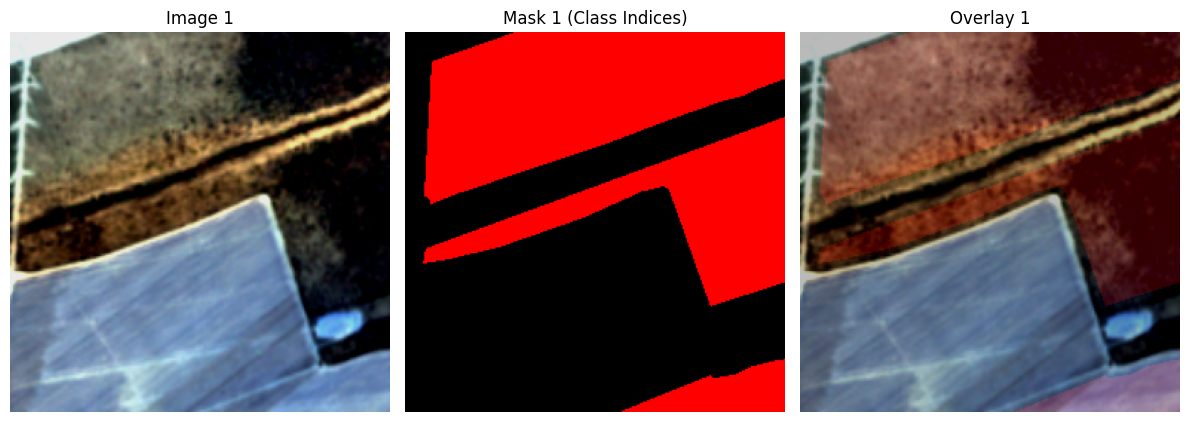

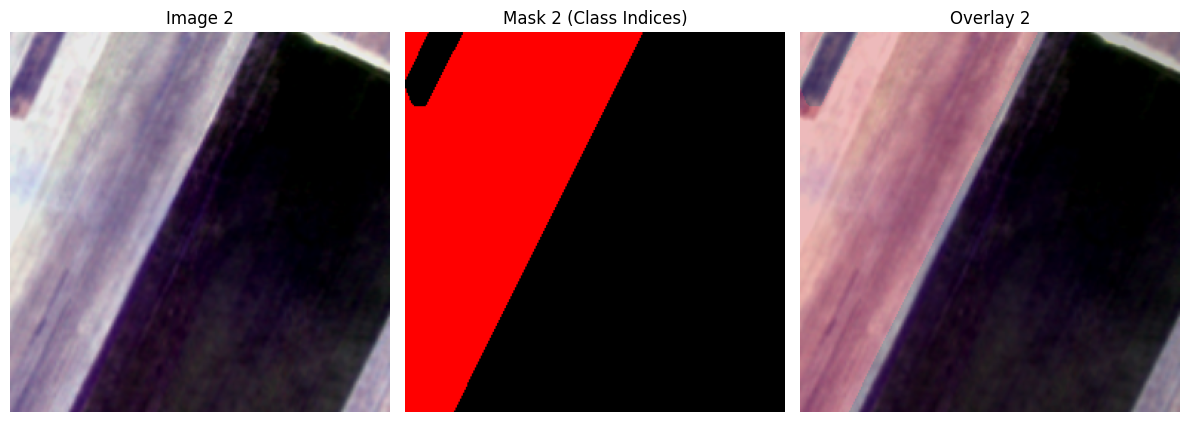

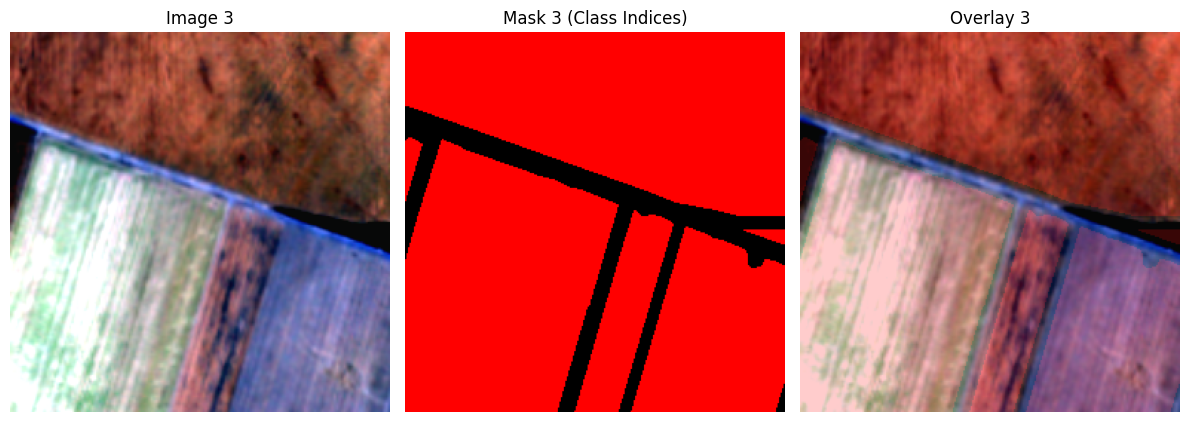

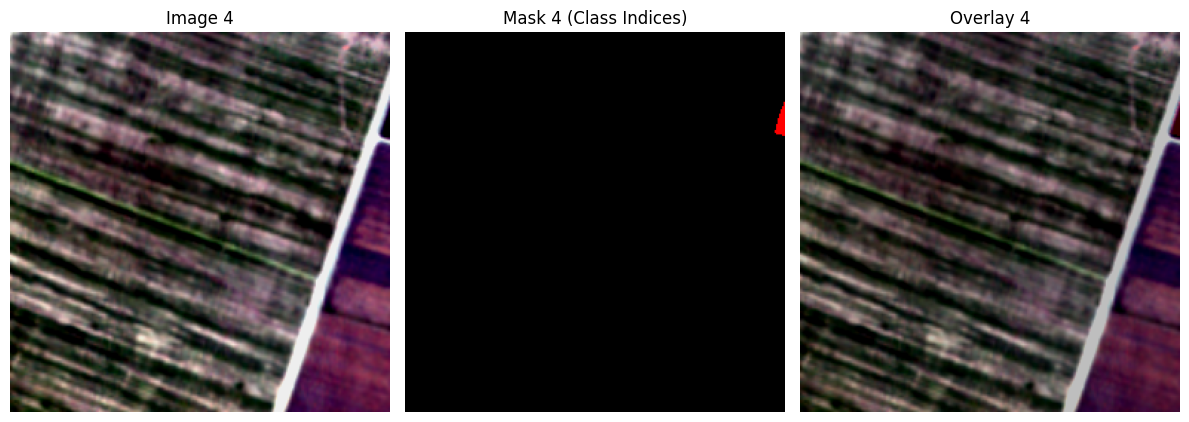

In [ ]:
images, masks = next(iter(train_generator))
print(f"Images shape: {images.shape}, Masks shape: {masks.shape}")

utils.plot_examples(images, masks, num_examples=4, figsize=(12, 17))

## Simple U-Net Model Implementation

Implementing a lightweight U-Net architecture for binary semantic segmentation.

In [ ]:
# Use He uniform initialization for better gradient flow
kernel_initializer = 'he_uniform'

################################################################
def simple_unet_model(IMG_SIZE):
    """
    Create a simple U-Net model for binary semantic segmentation.
    """

    inputs = Input(IMG_SIZE)

    #Contraction path
    c1 = Conv2D(16, (3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(inputs)
    c1 = Dropout(0.1)(c1)
    c1 = Conv2D(16, (3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    c2 = Conv2D(32, (3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(p1)
    c2 = Dropout(0.1)(c2)
    c2 = Conv2D(32, (3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    c3 = Conv2D(64, (3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(p2)
    c3 = Dropout(0.2)(c3)
    c3 = Conv2D(64, (3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c3)
    p3 = MaxPooling2D((2, 2))(c3)

    c4 = Conv2D(128, (3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(p3)
    c4 = Dropout(0.2)(c4)
    c4 = Conv2D(128, (3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c4)
    p4 = MaxPooling2D(pool_size=(2, 2))(c4)

    c5 = Conv2D(256, (3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(p4)
    c5 = Dropout(0.3)(c5)
    c5 = Conv2D(256, (3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c5)

    #Expansive path
    u6 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = concatenate([u6, c4])
    c6 = Conv2D(128, (3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(u6)
    c6 = Dropout(0.2)(c6)
    c6 = Conv2D(128, (3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c6)

    u7 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = concatenate([u7, c3])
    c7 = Conv2D(64, (3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(u7)
    c7 = Dropout(0.2)(c7)
    c7 = Conv2D(64, (3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c7)

    u8 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = concatenate([u8, c2])
    c8 = Conv2D(32, (3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(u8)
    c8 = Dropout(0.1)(c8)
    c8 = Conv2D(32, (3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c8)

    u9 = Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = concatenate([u9, c1], axis=3)
    c9 = Conv2D(16, (3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(u9)
    c9 = Dropout(0.1)(c9)
    c9 = Conv2D(16, (3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c9)

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c9)

    model = Model(inputs=[inputs], outputs=[outputs], name='simple_unet_model')

    return model

In [ ]:
# Create the U-Net model
model = simple_unet_model(IMAGE_SIZE)

# Visualize the model architecture
plot_model(model, to_file='cnn_model_architecture.png', show_shapes=True, show_layer_names=True)
print("Model architecture diagram saved to cnn_model_architecture.png")

Model architecture diagram saved to cnn_model_architecture.png


In [ ]:
model.summary()

Model: "simple_unet_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        448 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256, 256,  │          0 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      2,320 │ dropout[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128, 128,  │          0 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │      9,248 │ dropout_1[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64, 64,    │          0 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │     36,928 │ dropout_2[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32, 32,    │          0 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │    147,584 │ dropout_3[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]  

 Total params: 1,941,105 (7.40 MB)

 Trainable params: 1,941,105 (7.40 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Set learning rate and optimizer
LEARNING_RATE = 0.0001  # Conservative learning rate for stable training
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

# Compile model with appropriate loss and metrics for binary segmentation#model.summary()
model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',  # Standard loss for binary classification
    metrics=['accuracy',  # Pixel-wise accuracy
            keras.metrics.MeanIoU(num_classes=2)]  # Intersection over Union metric
)

In [ ]:
LOAD_WEIGHTS = False
simple_unet_model= "simple_unet_model.h5"
if os.path.exists(simple_unet_model) and LOAD_WEIGHTS:
    model.load_weights(simple_unet_model)

In [ ]:
# Train the model
history = model.fit(
    train_generator,
    epochs=25,  # Number of complete passes through the training data
    verbose=1,  # Print training progress
    validation_data=val_generator  # Evaluate on validation set each epoch
)

Epoch 1/25
240/240 ━━━━━━━━━━━━━━━━━━━━ 398s 2s/step - accuracy: 0.5352 - loss: 0.6914 - mean_io_u: 0.2170 - val_accuracy: 0.5812 - val_loss: 0.6794 - val_mean_io_u: 0.2115
Epoch 2/25
240/240 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - accuracy: 0.5829 - loss: 0.6756 - mean_io_u: 0.2128 - val_accuracy: 0.6156 - val_loss: 0.6603 - val_mean_io_u: 0.2115
Epoch 3/25
240/240 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - accuracy: 0.6314 - loss: 0.6525 - mean_io_u: 0.2086 - val_accuracy: 0.6593 - val_loss: 0.6357 - val_mean_io_u: 0.2115
Epoch 4/25
240/240 ━━━━━━━━━━━━━━━━━━━━ 13s 54ms/step - accuracy: 0.6329 - loss: 0.6467 - mean_io_u: 0.2145 - val_accuracy: 0.6520 - val_loss: 0.6325 - val_mean_io_u: 0.2115
Epoch 5/25
240/240 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.6422 - loss: 0.6388 - mean_io_u: 0.2176 - val_accuracy: 0.6568 - val_loss: 0.6298 - val_mean_io_u: 0.2115
Epoch 6/25
240/240 ━━━━━━━━━━━━━━━━━━━━ 13s 54ms/step - accuracy: 0.6581 - loss: 0.6264 - mean_io_u: 0.2072 - val_accuracy: 0.6618 

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 922ms/step


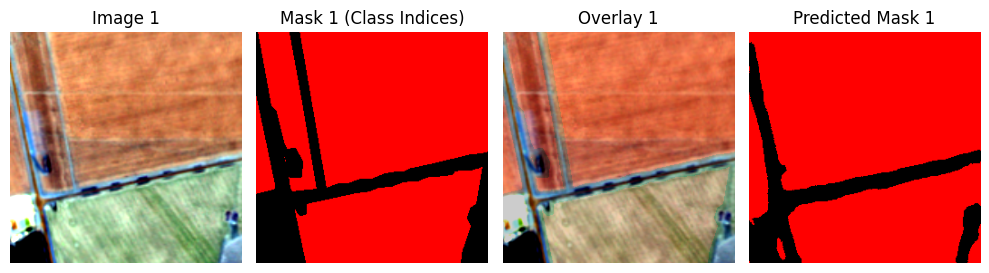

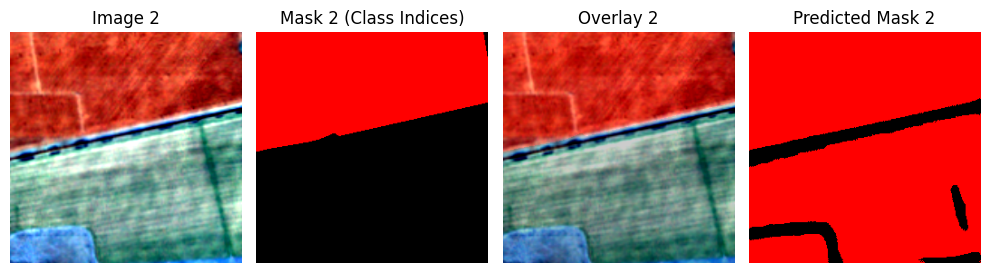

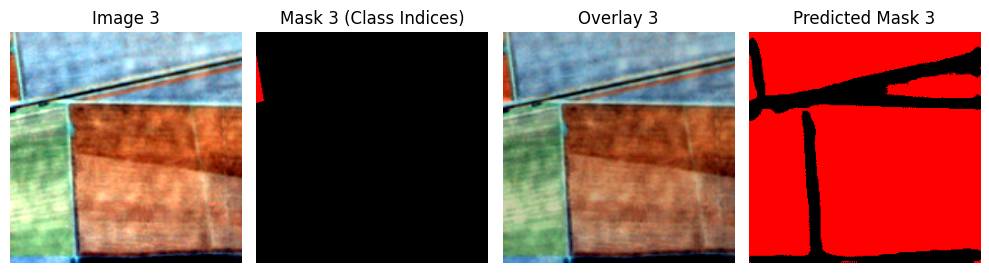

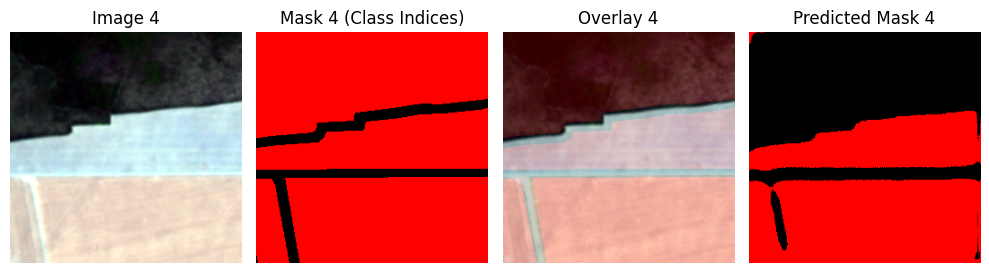

In [ ]:
# Get a batch of test data
test_images, test_masks = next(iter(test_generator))

# Make predictions
predictions = model.predict(test_images)

# Visualize results
utils.plot_examples(test_images, test_masks, pred_masks=predictions, num_examples=8, figsize=(10, 20))

In [ ]:
# Save the trained model for future use
model.save(f"/content/drive/MyDrive/Escuela/models/{simple_unet_model}")
keras.saving.save_model(model, '/content/drive/MyDrive/Escuela/models/simple_unet_model.keras')

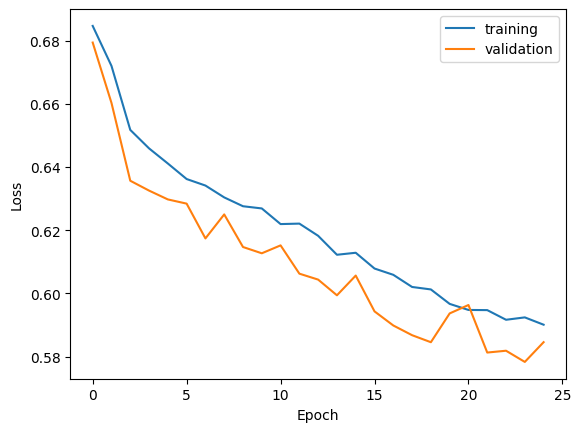

In [ ]:
plt.plot(history.epoch,history.history["loss"],label="training")
plt.plot(history.epoch,history.history["val_loss"],label="validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

In [ ]:
pd.DataFrame(history.history).to_csv('simple_unet_model_training_history.csv', index=False)

## Transfer learning using Segmentation Models library

This approach leverages transfer learning for potentially better performance.
Implementing U-Net with pre-trained encoder using the segmentation-models library.

In [ ]:
!pip install segmentation-models

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 5.5 MB/s eta 0:00:00


In [ ]:
os.environ["SM_FRAMEWORK"] = "tf.keras"

try:
    import segmentation_models as sm
    sm.set_framework('tf.keras')
except ImportError:
    # Install Segmentation-models library: https://segmentation-models.readthedocs.io/en/latest/
    print("segmentation_models library is not installed. Please install it using 'pip install segmentation_models'.")
    sm = None

Segmentation Models: using `tf.keras` framework.


In [ ]:
#############################################################################
# Use transfer learning using pretrained encoder in the U-Net
# (make sure you uncomment the preprocess_input part in the
# preprocess_data function above)
################################################################

# define model
BACKBONE = 'resnet34'  # You can change this to any other backbone supported by segmentation_models
model = sm.Unet(BACKBONE, encoder_weights='imagenet', encoder_freeze=True,
                input_shape=IMAGE_SIZE,
                classes=1, activation='sigmoid')

LEARNING_RATE = 0.0001
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
model.compile(optimizer=optimizer, loss=sm.losses.binary_crossentropy, metrics=[sm.metrics.iou_score,"accuracy"])

# Other losses to try: binary_focal_dice_loss, binary_focal_loss

#print(model.summary())

85521592/85521592 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
LOAD_WEIGHTS = False
unet_resnet34_model_weights = "unet_resnet34.h5"
if os.path.exists(unet_resnet34_model_weights) and LOAD_WEIGHTS:
    model.load_weights(unet_resnet34_model_weights)

In [ ]:
history = model.fit(train_generator,
                epochs=25,
                verbose=1,
                validation_data=val_generator
)

Epoch 1/25
240/240 ━━━━━━━━━━━━━━━━━━━━ 125s 254ms/step - accuracy: 0.5801 - iou_score: 0.4106 - loss: 0.6851 - val_accuracy: 0.5767 - val_iou_score: 0.4024 - val_loss: 0.6883
Epoch 2/25
240/240 ━━━━━━━━━━━━━━━━━━━━ 19s 80ms/step - accuracy: 0.6665 - iou_score: 0.4468 - loss: 0.6182 - val_accuracy: 0.5771 - val_iou_score: 0.4499 - val_loss: 0.7166
Epoch 3/25
240/240 ━━━━━━━━━━━━━━━━━━━━ 20s 83ms/step - accuracy: 0.6875 - iou_score: 0.4588 - loss: 0.5956 - val_accuracy: 0.6056 - val_iou_score: 0.4613 - val_loss: 0.6732
Epoch 4/25
240/240 ━━━━━━━━━━━━━━━━━━━━ 19s 79ms/step - accuracy: 0.6882 - iou_score: 0.4722 - loss: 0.5961 - val_accuracy: 0.6915 - val_iou_score: 0.4571 - val_loss: 0.5894
Epoch 5/25
240/240 ━━━━━━━━━━━━━━━━━━━━ 20s 81ms/step - accuracy: 0.6774 - iou_score: 0.4519 - loss: 0.5984 - val_accuracy: 0.7261 - val_iou_score: 0.4944 - val_loss: 0.5596
Epoch 6/25
240/240 ━━━━━━━━━━━━━━━━━━━━ 20s 83ms/step - accuracy: 0.7042 - iou_score: 0.4832 - loss: 0.5751 - val_accuracy: 0.73

In [ ]:
# Save the trained model for future use
model.save(f"/content/drive/MyDrive/Escuela/models/{unet_resnet34_model_weights}")
keras.saving.save_model(model, '/content/drive/MyDrive/Escuela/models/unet_resnet34.keras')

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


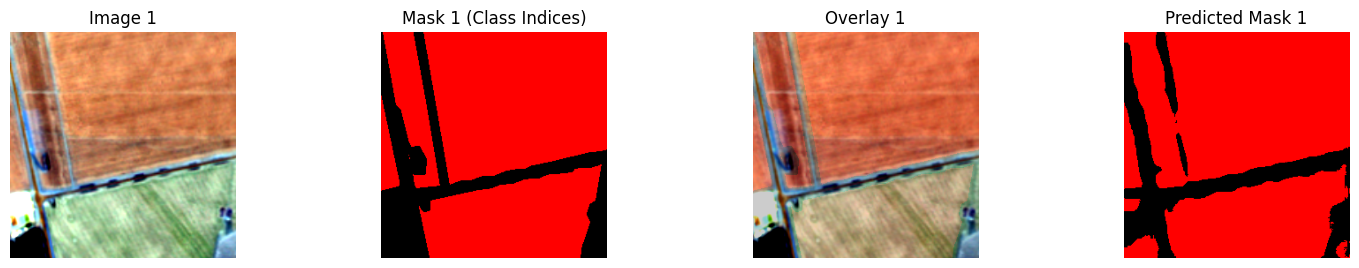

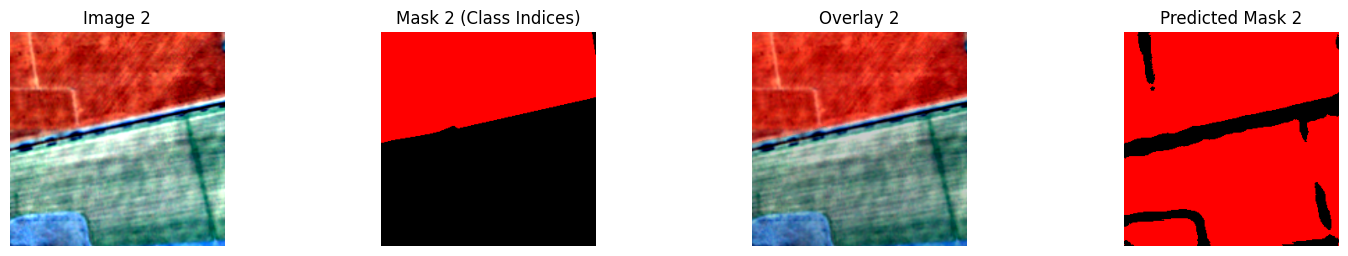

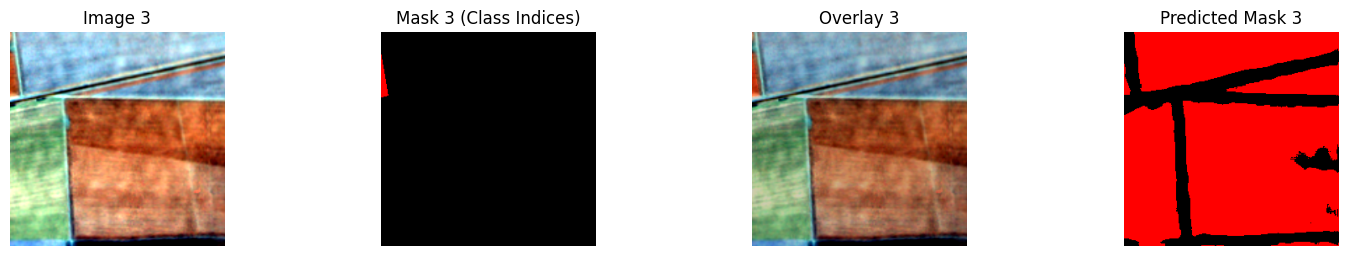

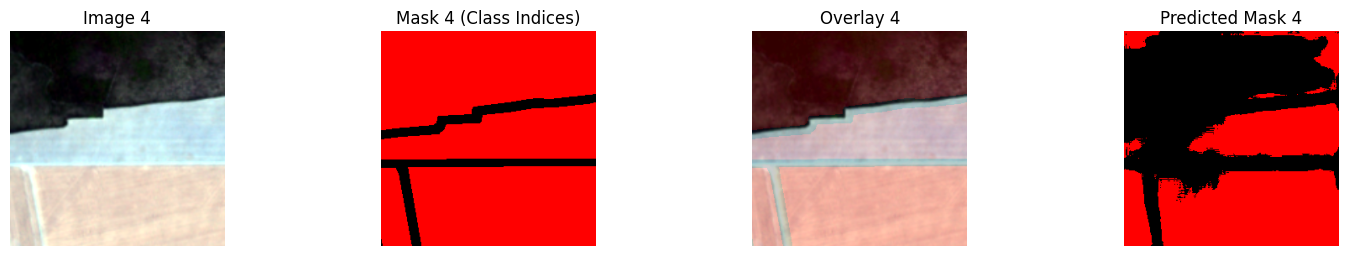

In [ ]:
# Get a batch of test data
test_images, test_masks = next(iter(test_generator))

# Make predictions
predictions = model.predict(test_images)

# Visualize results
utils.plot_examples(test_images, test_masks, pred_masks=predictions, num_examples=4, figsize=(15, 10), alpha=0.5)

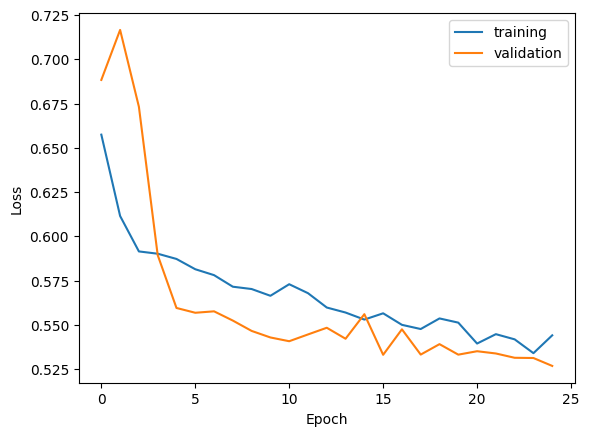

In [ ]:
plt.plot(history.epoch,history.history["loss"],label="training")
plt.plot(history.epoch,history.history["val_loss"],label="validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

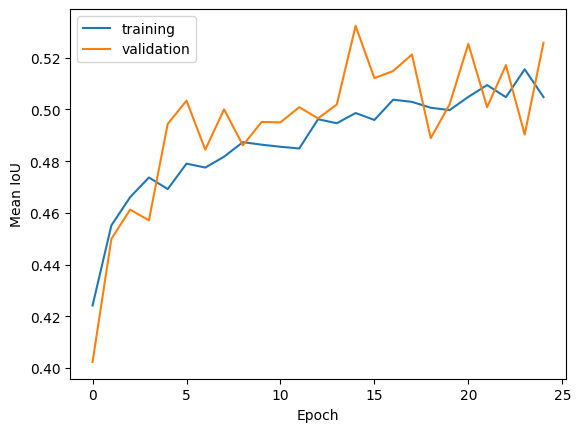

In [ ]:
plt.plot(history.epoch,history.history["iou_score"],label="training")
plt.plot(history.epoch,history.history["val_iou_score"],label="validation")
plt.xlabel("Epoch")
plt.ylabel("Mean IoU")
plt.legend()

In [ ]:
pd.DataFrame(history.history).to_csv('/content/drive/MyDrive/Escuela/models/unet_resnet34_training_history.csv', index=False)

## Using more than 3 bands

In [ ]:
# Directory configuration and dataset parameters
ROOT_DIR = f"brazil/processed_data"

train_images_dir = f"{ROOT_DIR}/train/window_a/tif/"
train_masks_dir = f"{ROOT_DIR}/train/masks_2class"
val_images_dir = f"{ROOT_DIR}/val/window_a/tif/"
val_masks_dir = f"{ROOT_DIR}/val/masks_2class"
test_images_dir = f"{ROOT_DIR}/test/window_a/tif/"
test_masks_dir = f"{ROOT_DIR}/test/masks_2class"

TARGET_SIZE = 256  # Input image size for the model

# Define class labels for binary segmentation
CLASSES = {0: 'Background', 1: 'Cropland'}
NCLASSES = 2

In [ ]:
train_generator = utils.create_multiclass_segmentation_generator_tiff(
    image_dir=train_images_dir,
    mask_dir=train_masks_dir,
    batch_size=4,
    image_size=(256,256),
    shuffle=True,
    augmentation=False,
    seed=147
)

test_generator = utils.create_multiclass_segmentation_generator_tiff(
    image_dir=test_images_dir,
    mask_dir=test_masks_dir,
    batch_size=4,
    image_size=(256,256),
    shuffle=True,
    augmentation=False,
    seed=147
)

val_generator = utils.create_multiclass_segmentation_generator_tiff(
    image_dir=val_images_dir,
    mask_dir=val_masks_dir,
    batch_size=4,
    image_size=(256,256),
    shuffle=True,
    augmentation=False,
    seed=147
)

In [ ]:
# Take a sample batch to inspect data shapes and values
for images, masks in train_generator.take(1):
    print("Images shape:", images.shape)
    print("Masks shape:", masks.shape)
    print("Unique values in masks:", tf.unique(tf.reshape(masks, [-1])))
    print("Mask range:", tf.reduce_min(masks).numpy(), "to", tf.reduce_max(masks).numpy())

    # Verify if masks are truly binary
    unique_vals = tf.unique(tf.reshape(masks, [-1])).y.numpy()
    print("Exact unique values:", unique_vals)

    IMAGE_SIZE = tuple(images.shape[1:])

Images shape: (4, 256, 256, 4)
Masks shape: (4, 256, 256, 1)
Unique values in masks: Unique(y=<tf.Tensor: shape=(2,), dtype=float32, numpy=array([1., 0.], dtype=float32)>, idx=<tf.Tensor: shape=(262144,), dtype=int32, numpy=array([0, 0, 0, ..., 0, 0, 0], shape=(262144,), dtype=int32)>)
Mask range: 0.0 to 1.0
Exact unique values: [1. 0.]


Images shape: (4, 256, 256, 4), Masks shape: (4, 256, 256, 1)


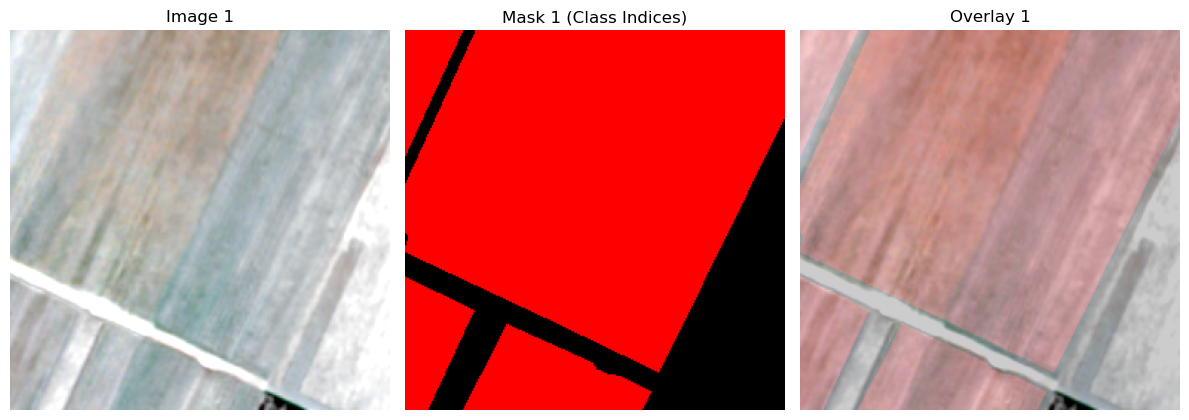

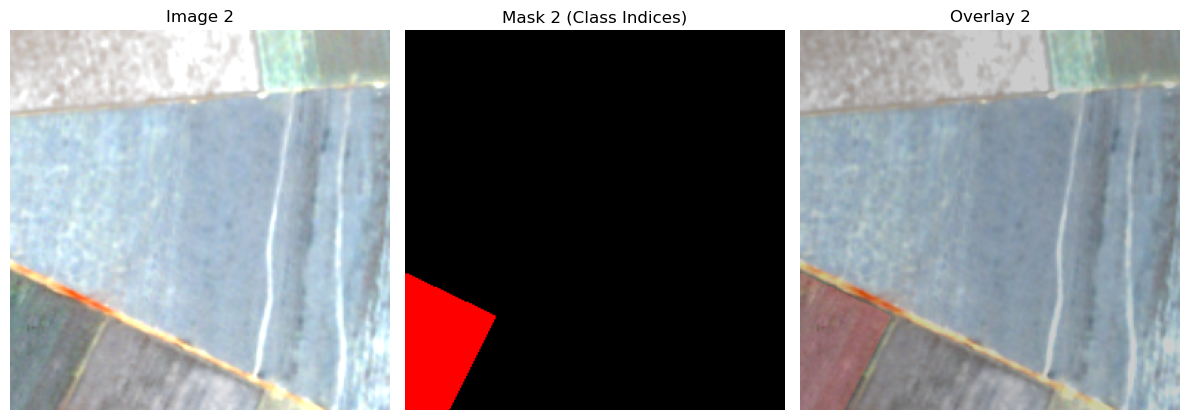

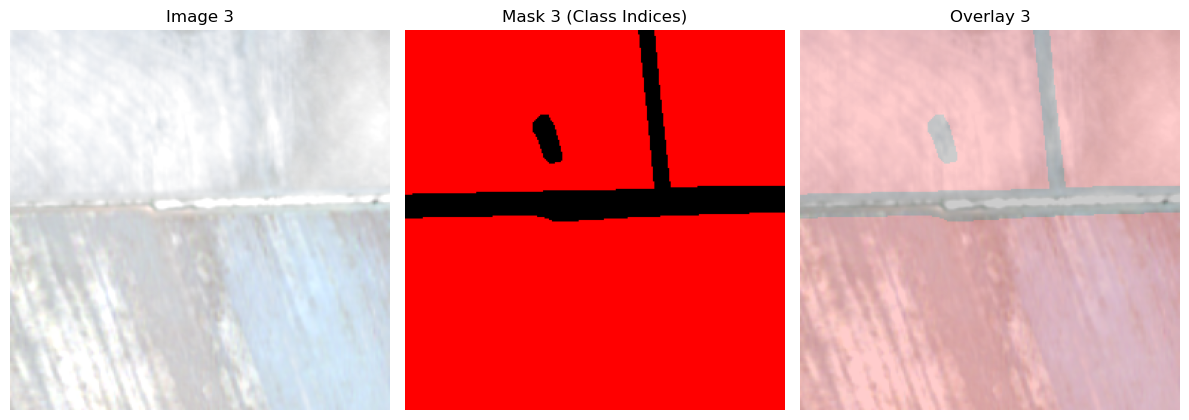

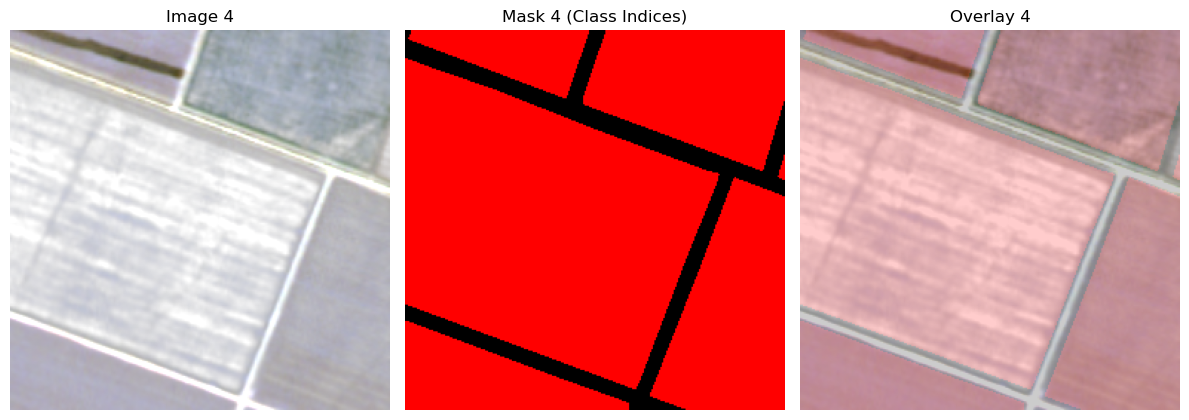

In [ ]:
images, masks = next(iter(train_generator))
print(f"Images shape: {images.shape}, Masks shape: {masks.shape}")

utils.plot_examples(images, masks, num_examples=4, figsize=(12, 17))

In [ ]:
# Create the U-Net model
model = simple_unet_model(IMAGE_SIZE)

# Visualize the model architecture
plot_model(model, to_file='cnn_model_architecture.png', show_shapes=True, show_layer_names=True)
print("Model architecture diagram saved to cnn_model_architecture.png")

In [ ]:
# Set learning rate and optimizer
LEARNING_RATE = 0.0001  # Conservative learning rate for stable training
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

# Compile model with appropriate loss and metrics for binary segmentation#model.summary()
model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',  # Standard loss for binary classification
    metrics=['accuracy',  # Pixel-wise accuracy
            keras.metrics.MeanIoU(num_classes=2)]  # Intersection over Union metric
)

In [ ]:
LOAD_WEIGHTS = False
simple_unet_model= "simple_unet_model.h5"
if os.path.exists(simple_unet_model) and LOAD_WEIGHTS:
    model.load_weights(simple_unet_model)

In [ ]:
# Train the model
history = model.fit(
    train_generator,
    epochs=25,  # Number of complete passes through the training data
    verbose=1,  # Print training progress
    validation_data=val_generator  # Evaluate on validation set each epoch
)

In [ ]:
# Get a batch of test data
test_images, test_masks = next(iter(test_generator))

# Make predictions
predictions = model.predict(test_images)

# Visualize results
utils.plot_examples(test_images, test_masks, pred_masks=predictions, num_examples=8, figsize=(10, 20))

In [ ]:
# Save the trained model for future use
model.save(simple_unet_model)
keras.saving.save_model(model, 'simple_unet_model.keras')

In [ ]:
plt.plot(history.epoch,history.history["loss"],label="training")
plt.plot(history.epoch,history.history["val_loss"],label="validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()